In [ ]:
import time
import os
import warnings
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

from datetime import datetime, timedelta
from textblob import TextBlob
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
!pip install gensim
from gensim.models import Word2Vec

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

nltk.download("punkt_tab",     quiet=True)
nltk.download("stopwords", quiet=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.0 MB/s eta 0:00:00


True

In [ ]:
# import data hasil scrapping
df_im3 = pd.read_csv('data_review_im3.csv')
df_im3.head(10)

,username,rating pengguna,review,tanggal
0,Pengguna Google,1,saya beli paket data.sudah di teranfer tapi ku...,2026-06-22 13:36:05
1,Pengguna Google,5,main game,2026-06-22 13:30:16
2,Pengguna Google,5,lancar jaya,2026-06-22 13:27:17
3,Pengguna Google,1,sinyal jelek,2026-06-22 13:25:15
4,Pengguna Google,1,jaringannya super JELEK JAKARTA BARAT SERENGSENG,2026-06-22 13:24:20
5,Pengguna Google,1,tolong jaringan m3 mohon di perbaiki lagi dong...,2026-06-22 13:23:51
6,Pengguna Google,5,Bgus kalau bisa kalau pas mati lampu jaringan ...,2026-06-22 13:16:12
7,Pengguna Google,5,aplikasinya bagus,2026-06-22 13:14:33
8,Pengguna Google,5,sangat murah,2026-06-22 13:13:26
9,Pengguna Google,5,bagus sangat bagus dan amanah,2026-06-22 13:05:21


### Preprocessing

In [ ]:
df_im3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91734 entries, 0 to 91733
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   username         91734 non-null  object
 1   rating pengguna  91734 non-null  int64 
 2   review           91734 non-null  object
 3   tanggal          91734 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.8+ MB


In [ ]:
# ubah data type "tanggal" menjadi DateTime
df_im3['tanggal'] = pd.to_datetime(df_im3['tanggal'])
df_im3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91734 entries, 0 to 91733
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   username         91734 non-null  object        
 1   rating pengguna  91734 non-null  int64         
 2   review           91734 non-null  object        
 3   tanggal          91734 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 2.8+ MB


In [ ]:
# cleaning text
import re
import string

def clean_text(text):
    """Menghapus elemen tidak relevan dari teks review"""
    text = str(text)
    # Hapus mention (@username)
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text)
    # Hapus hashtag (#)
    text = re.sub(r"#[A-Za-z0-9_]+", " ", text)
    # Hapus URL
    text = re.sub(r"(http|https)://\S+|www\.\S+", " ", text)
    # Hapus emoji dan karakter aneh (Â², ðŸ‘Š, dll)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    # Hapus angka
    text = re.sub(r"[0-9]+", " ", text)
    # Hapus tanda baca
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Hanya huruf dan spasi
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    # Hapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_im3["review_cleaned"] = df_im3["review"].apply(clean_text)
df_im3[["review", "review_cleaned"]].head()


,review,review_cleaned
0,saya beli paket data.sudah di teranfer tapi ku...,saya beli paket datasudah di teranfer tapi kua...
1,main game,main game
2,lancar jaya,lancar jaya
3,sinyal jelek,sinyal jelek
4,jaringannya super JELEK JAKARTA BARAT SERENGSENG,jaringannya super JELEK JAKARTA BARAT SERENGSENG


In [ ]:
# Case Folding (lowercase)
df_im3['text_casefold'] = df_im3['review_cleaned'].str.lower()
df_im3[['review_cleaned', 'text_casefold']].head()

,review_cleaned,text_casefold
0,saya beli paket datasudah di teranfer tapi kua...,saya beli paket datasudah di teranfer tapi kua...
1,main game,main game
2,lancar jaya,lancar jaya
3,sinyal jelek,sinyal jelek
4,jaringannya super JELEK JAKARTA BARAT SERENGSENG,jaringannya super jelek jakarta barat serengseng


In [ ]:
# tokenizing
from nltk.tokenize import sent_tokenize, word_tokenize

df_im3['text_tokenized'] = df_im3['text_casefold'].apply(word_tokenize)
df_im3[['text_casefold', 'text_tokenized']].head()

,text_casefold,text_tokenized
0,saya beli paket datasudah di teranfer tapi kua...,"[saya, beli, paket, datasudah, di, teranfer, t..."
1,main game,"[main, game]"
2,lancar jaya,"[lancar, jaya]"
3,sinyal jelek,"[sinyal, jelek]"
4,jaringannya super jelek jakarta barat serengseng,"[jaringannya, super, jelek, jakarta, barat, se..."


In [ ]:
# normalization
df_kamus_normalisasi = pd.read_excel('kamus_normalisasi.xlsx')
normalization_dict = dict(zip(df_kamus_normalisasi["slang"], df_kamus_normalisasi["formal"]))

def normalize_text(tokens):
    """Normalisasi kata tidak baku berdasarkan referensi dari dictionary Excel"""
    # Mengantisipasi jika baris kosong / bukan berupa list token
    if not isinstance(tokens, list):
        return []

    normalized = []
    for token in tokens:
        # Mengubah ke string dan lowercase agar pencarian di dictionary cocok
        token_str = str(token).lower()

        if token_str in normalization_dict:
            token_baru = normalization_dict[token_str]

            # Jika di excel kolom bakunya kosong/NaN, atau berisi string kosong, token diabaikan (dihapus)
            if pd.notna(token_baru) and token_baru != "":
                normalized.append(str(token_baru).lower())
        else:
            normalized.append(token_str)
    return normalized

df_im3["text_normalized"] = df_im3["text_tokenized"].apply(normalize_text)
df_im3[["text_tokenized", "text_normalized"]].head()


,text_tokenized,text_normalized
0,"[saya, beli, paket, datasudah, di, teranfer, t...","[saya, beli, paket, datasudah, di, teranfer, t..."
1,"[main, game]","[main, game]"
2,"[lancar, jaya]","[lancar, jaya]"
3,"[sinyal, jelek]","[sinyal, jelek]"
4,"[jaringannya, super, jelek, jakarta, barat, se...","[jaringannya, super, jelek, jakarta, barat, se..."


In [ ]:
# Stopword Removal
stopwords_indonesia = {
    'yang', 'dan', 'di', 'dari', 'ini', 'itu', 'adalah', 'untuk', 'dengan',
    'pada', 'ke', 'dapat', 'dapatkan', 'bisa', 'juga', 'saya', 'anda', 'kami',
    'kita', 'mereka', 'dia', 'ia', 'kamu', 'aku', 'kalian', 'ku', 'mu', 'nya',
    'pakai', 'tanpa', 'atau', 'sebagai', 'dalam', 'oleh', 'karena', 'sebab',
    'jika', 'kalau', 'maka', 'tapi', 'tetapi', 'namun', 'sedangkan', 'sementara',
    'bahwa', 'sehingga', 'supaya', 'agar', 'apakah', 'akan', 'telah', 'sudah',
    'sedang', 'masih', 'lagi', 'pun', 'pernah', 'selalu', 'sering', 'kadang',
    'jarang', 'biasa', 'terus', 'saja', 'sangat', 'amat', 'sekali', 'benar',
    'cukup', 'agak', 'kurang', 'lebih', 'paling', 'terlalu', 'sungguh',
    'begitu', 'demikian', 'begini', 'seperti', 'bagai', 'ibarat', 'laksana',
    'wao', 'wow', 'woow', 'hahaha', 'wkwk', 'wkwkwk', 'hehe', 'hihi'
}

def remove_stopwords(tokens):
    """Menghapus stopword dari token"""
    return [token for token in tokens if token.lower() not in stopwords_indonesia and len(token) > 1]

df_im3['text_stopword'] = df_im3['text_normalized'].apply(remove_stopwords)

In [ ]:
from multiprocessing import Pool, cpu_count
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# 1. Inisialisasi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()


# 2. Fungsi Pekerja Stemming
def stem_row(tokens):
    if not isinstance(tokens, list) or len(tokens) == 0:
        return []
    kalimat_sementara = " ".join(tokens)
    kalimat_terstem = stemmer.stem(kalimat_sementara)
    return kalimat_terstem.split()


# 3. Eksekusi Paralel (Langsung jalankan di cell Colab Anda)
jumlah_core = cpu_count()
print(f"Server Google Colab Menyediakan: {jumlah_core} CPU Core.")
print(
    f"Memulai stemming paralel 90.000 data pada server Google..."
)

# Membuka pool untuk membagi tugas ke core server Google
with Pool(processes=jumlah_core) as pool:
    hasil_paralel = pool.map(stem_row, df_im3["text_stopword"])

# Masukkan ke DataFrame
df_im3["text_stemmed"] = hasil_paralel

print("\n✅ Preprocessing di Google Colab Selesai!")
print(df_im3[["text_stopword", "text_stemmed"]].head())

Server Google Colab Menyediakan: 2 CPU Core.
Memulai stemming paralel 90.000 data pada server Google...

✅ Preprocessing di Google Colab Selesai!
                                       text_stopword  \
0  [beli, paket, datasudah, teranfer, kuata, engg...   
1                                       [main, game]   
2                                     [lancar, jaya]   
3                                    [sinyal, jelek]   
4  [jaringannya, super, jelek, jakarta, barat, se...   

                                        text_stemmed  
0  [beli, paket, datasudah, teranfer, kuata, engg...  
1                                       [main, game]  
2                                     [lancar, jaya]  
3                                    [sinyal, jelek]  
4  [jaring, super, jelek, jakarta, barat, serengs...  


In [ ]:
df_im3.to_csv('data_review_im3_preprocessed.csv', index=False)

### Labeling untuk DF im3

In [ ]:
df_preproc = pd.read_csv('data_review_im3_preprocessed.csv')
df_preproc.head()

,username,rating pengguna,review,tanggal,review_cleaned,text_casefold,text_tokenized,text_normalized,text_stopword,text_stemmed
0,Pengguna Google,1,saya beli paket data.sudah di teranfer tapi ku...,2026-06-22 13:36:05,saya beli paket datasudah di teranfer tapi kua...,saya beli paket datasudah di teranfer tapi kua...,"['saya', 'beli', 'paket', 'datasudah', 'di', '...","['saya', 'beli', 'paket', 'datasudah', 'di', '...","['beli', 'paket', 'datasudah', 'teranfer', 'ku...","['beli', 'paket', 'datasudah', 'teranfer', 'ku..."
1,Pengguna Google,5,main game,2026-06-22 13:30:16,main game,main game,"['main', 'game']","['main', 'game']","['main', 'game']","['main', 'game']"
2,Pengguna Google,5,lancar jaya,2026-06-22 13:27:17,lancar jaya,lancar jaya,"['lancar', 'jaya']","['lancar', 'jaya']","['lancar', 'jaya']","['lancar', 'jaya']"
3,Pengguna Google,1,sinyal jelek,2026-06-22 13:25:15,sinyal jelek,sinyal jelek,"['sinyal', 'jelek']","['sinyal', 'jelek']","['sinyal', 'jelek']","['sinyal', 'jelek']"
4,Pengguna Google,1,jaringannya super JELEK JAKARTA BARAT SERENGSENG,2026-06-22 13:24:20,jaringannya super JELEK JAKARTA BARAT SERENGSENG,jaringannya super jelek jakarta barat serengseng,"['jaringannya', 'super', 'jelek', 'jakarta', '...","['jaringannya', 'super', 'jelek', 'jakarta', '...","['jaringannya', 'super', 'jelek', 'jakarta', '...","['jaring', 'super', 'jelek', 'jakarta', 'barat..."


In [ ]:
# cek tipe data kolom "text_stemmed"
print(type(df_preproc["text_stemmed"].iloc[0]))

<class 'str'>


In [ ]:
# ubah tipe string ke bentuk list untuk labeling
import ast

df_preproc["text_stemmed"] = df_preproc["text_stemmed"].apply(
    ast.literal_eval
)

In [ ]:
# Load leksikon INSET Positif dan Negatif langsung dari GitHub
url_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
url_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

df_pos = pd.read_csv(url_pos, sep="\t")
df_neg = pd.read_csv(url_neg, sep="\t")

# Ubah ke dalam bentuk dictionary {kata: skor}
inset_dict = dict(zip(df_pos["word"], df_pos["weight"]))
inset_dict.update(dict(zip(df_neg["word"], df_neg["weight"])))

In [ ]:
def kalkulasi_sentimen(list_kata):
    """Menghitung skor berdasarkan list kata hasil stemming"""
    # Mengantisipasi jika ada baris kosong/bukan list
    if not isinstance(list_kata, list) or len(list_kata) == 0:
        return 0, "Netral"

    # LANGSUNG HITUNG: karena sudah berbentuk list kata, tidak perlu .split() lagi
    score = sum(inset_dict.get(word, 0) for word in list_kata)

    # Penentuan aturan keputusan label
    if score > 0:
        label = "Positif"
    elif score < 0:
        label = "Negatif"
    else:
        label = "Netral"

    return score, label

df_preproc["skor_inset"], df_preproc["sentimen_lexicon"] = zip(
    *df_preproc["text_stemmed"].apply(kalkulasi_sentimen)
)

print("\n✅ Proses Pelabelan Leksikon Selesai!")
print("\n[Jumlah Frekuensi Kelas Sentimen]")
print(df_preproc["sentimen_lexicon"].value_counts())

print("\n[Persentase Proporsi Kelas Sentimen]")
print(df_preproc["sentimen_lexicon"].value_counts(normalize=True) * 100)

# Menampilkan 5 sampel data teratas hasil penyambungan
df_preproc[["text_stemmed", "skor_inset", "sentimen_lexicon"]].head()


✅ Proses Pelabelan Leksikon Selesai!

[Jumlah Frekuensi Kelas Sentimen]
sentimen_lexicon
Negatif    55603
Positif    26620
Netral      9511
Name: count, dtype: int64

[Persentase Proporsi Kelas Sentimen]
sentimen_lexicon
Negatif    60.613295
Positif    29.018684
Netral     10.368021
Name: proportion, dtype: float64


,text_stemmed,skor_inset,sentimen_lexicon
0,"[beli, paket, datasudah, teranfer, kuata, engg...",2,Positif
1,"[main, game]",0,Netral
2,"[lancar, jaya]",2,Positif
3,"[sinyal, jelek]",-5,Negatif
4,"[jaring, super, jelek, jakarta, barat, serengs...",-4,Negatif


In [ ]:
# split data
x = df_preproc['text_stemmed'].tolist()
y = df_preproc['sentimen_lexicon'].values

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data latih: {len(x_train)} sampel")
print(f"Data uji: {len(x_test)} sampel")
print("\nDistribusi label data latih:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c}")

Data latih: 73387 sampel
Data uji: 18347 sampel

Distribusi label data latih:
  Negatif: 44482
  Netral: 7609
  Positif: 21296


### Word embedding

In [ ]:
# word2vec embedding
w2v_model = Word2Vec(
    sentences=x_train,
    vector_size=150,
    window=1,
    min_count=1,
    sg=0,
    epochs=100,
    workers=4,
    seed=42
)

def get_avg_embedding(tokens, model, size=150):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(size)

x_train_w2v = np.array([get_avg_embedding(t, w2v_model) for t in x_train])
x_test_w2v = np.array([get_avg_embedding(t, w2v_model) for t in x_test])

print(f"✅ Word2Vec selesai!")
print(f"Shape train: {x_train_w2v.shape}")
print(f"Shape test: {x_test_w2v.shape}")

✅ Word2Vec selesai!
Shape train: (73387, 150)
Shape test: (18347, 150)


### Latih model

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Inisialisasi LabelEncoder
le = LabelEncoder()

# Mengubah target string menjadi angka (0 = Negatif, 1 = Netral, 2 = Positif)
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Menyimpan urutan kelas asli untuk evaluasi nanti
target_names = le.classes_  # Array(['Negatif', 'Netral', 'Positif'])

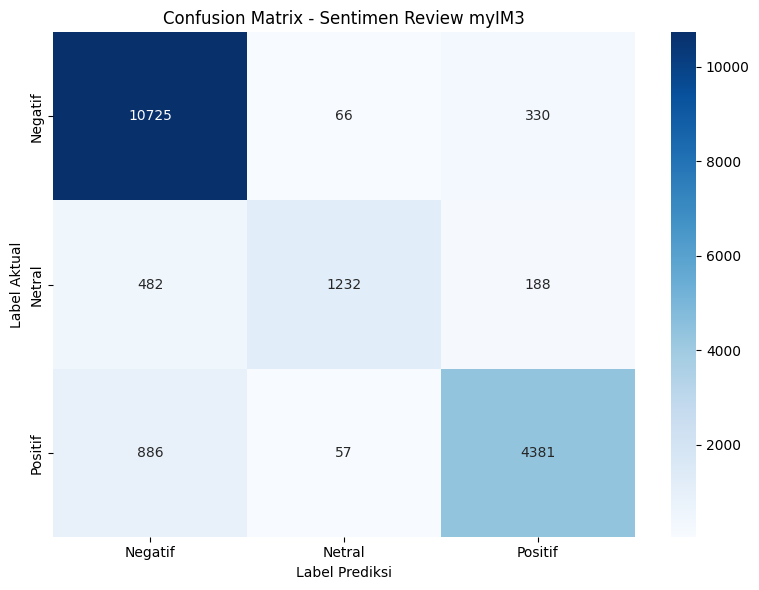

Akurasi Model SVM: 89.05%

[Classification Report - SVM]
              precision    recall  f1-score   support

     Negatif       0.89      0.96      0.92     11121
      Netral       0.91      0.65      0.76      1902
     Positif       0.89      0.82      0.86      5324

    accuracy                           0.89     18347
   macro avg       0.90      0.81      0.85     18347
weighted avg       0.89      0.89      0.89     18347



In [ ]:
from sklearn.svm import LinearSVC

# Latih data train
svm_model = LinearSVC(random_state=42, C=1.0, max_iter=2000)
svm_model.fit(x_train_w2v, y_train_encoded)

# Prediksi data test
y_pred_svm = svm_model.predict(x_test_w2v)

# Menghitung confusion matrix dari label aktual dan prediksi
cm = confusion_matrix(y_test_encoded, y_pred_svm)

# Membuat visualisasi heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)

# Mengatur detail label teks pada grafik
plt.title("Confusion Matrix - Sentimen Review myIM3")
plt.xlabel("Label Prediksi")
plt.ylabel("Label Aktual")
plt.tight_layout()
plt.show()

# Evaluasi Akurasi
akurasi_svm = accuracy_score(y_test_encoded, y_pred_svm)
print(f"Akurasi Model SVM: {akurasi_svm * 100:.2f}%")

# Classification Report
print("\n[Classification Report - SVM]")
print(classification_report(y_test_encoded, y_pred_svm, target_names=target_names))

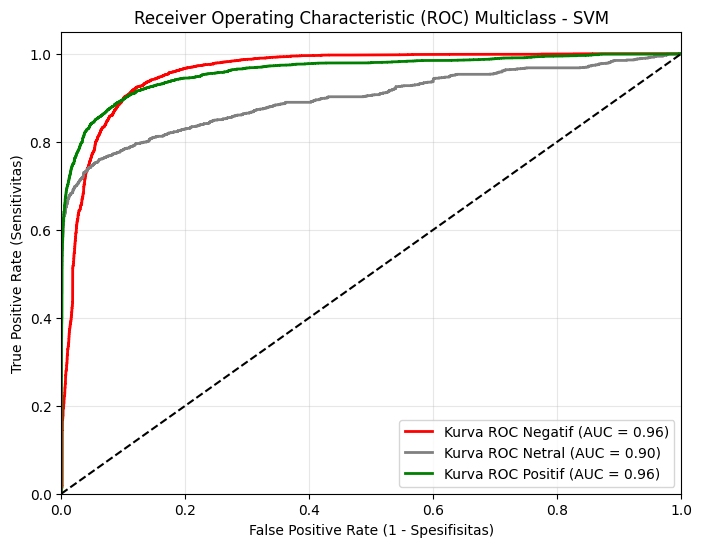

======= RINGKASAN EVALUASI AUC INTEGRAL =======
Skor AUC untuk Kelas Negatif: 0.9588
Skor AUC untuk Kelas Netral: 0.8968
Skor AUC untuk Kelas Positif: 0.9601


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve
from sklearn.preprocessing import label_binarize

# Mengubah target menjadi bentuk matriks biner sekuensial (One-vs-Rest)
# [0] -> [1, 0, 0], [1] -> [0, 1, 0], [2] -> [0, 0, 1]
y_test_binarized = label_binarize(y_test_encoded, classes=[0, 1, 2])
n_classes = y_test_binarized.shape[1]

y_score = svm_model.decision_function(x_test_w2v)

# Dictionary untuk menampung false positive rate, true positive rate, dan nilai AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

# menghitung ROC dan AUC per kelas sentimen
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(8, 6))

# Warna perwakilan untuk masing-masing kelas sentimen
colors = ["red", "gray", "green"]

for i, color in enumerate(colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"Kurva ROC {target_names[i]} (AUC = {roc_auc[i]:.2f})",
    )

# Membuat Garis Diagonal Tengah (Garis Tebakan Acak/Chance)
plt.plot([0, 1], [0, 1], color="black", lw=1.5, linestyle="--")

# Aturan layout dan teks grafik
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Spesifisitas)")
plt.ylabel("True Positive Rate (Sensitivitas)")
plt.title("Receiver Operating Characteristic (ROC) Multiclass - SVM")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print("======= RINGKASAN EVALUASI AUC =======")
for i in range(n_classes):
    print(f"Skor AUC untuk Kelas {target_names[i]}: {roc_auc[i]:.4f}")

### Visualisasi

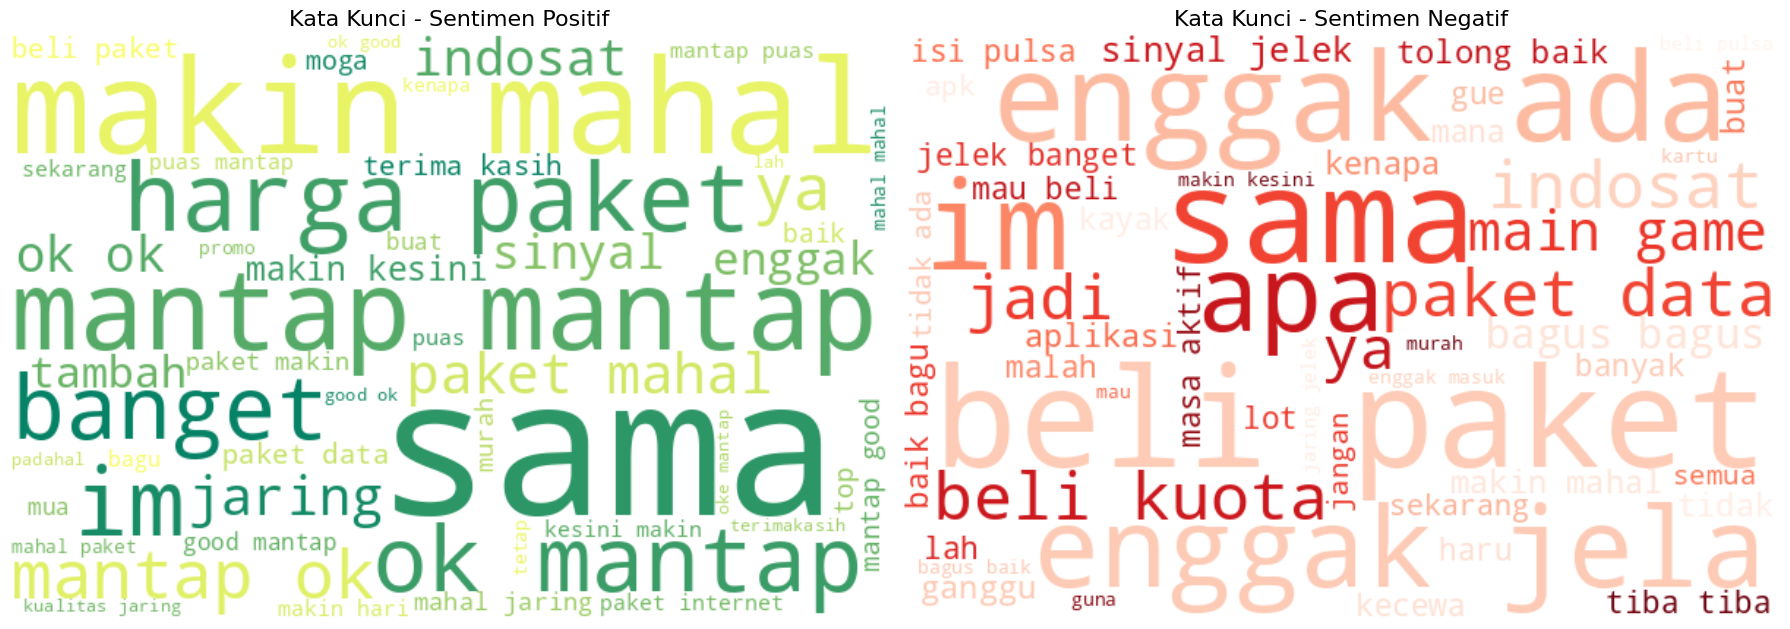

In [ ]:
# Memfilter teks berdasarkan label sentimen
teks_positif = " ".join(
    [
        " ".join(teks)
        for teks in df_preproc[
            df_preproc["sentimen_lexicon"] == "Positif"
        ]["text_stemmed"]
    ]
)
teks_negatif = " ".join(
    [
        " ".join(teks)
        for teks in df_preproc[
            df_preproc["sentimen_lexicon"] == "Negatif"
        ]["text_stemmed"]
    ]
)

# Set pola grid gambar berdampingan (1 baris, 2 kolom)
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Word Cloud Sentimen Positif
wc_pos = WordCloud(
    width=600,
    height=400,
    background_color="white",
    colormap="summer",
    max_words=50,
).generate(teks_positif)
ax[0].imshow(wc_pos, interpolation="bilinear")
ax[0].axis("off")
ax[0].set_title("Kata Kunci - Sentimen Positif", fontsize=16)

# Word Cloud Sentimen Negatif
wc_neg = WordCloud(
    width=600,
    height=400,
    background_color="white",
    colormap="Reds",
    max_words=50,
).generate(teks_negatif)
ax[1].imshow(wc_neg, interpolation="bilinear")
ax[1].axis("off")
ax[1].set_title("Kata Kunci - Sentimen Negatif", fontsize=16)

plt.tight_layout()
plt.show()

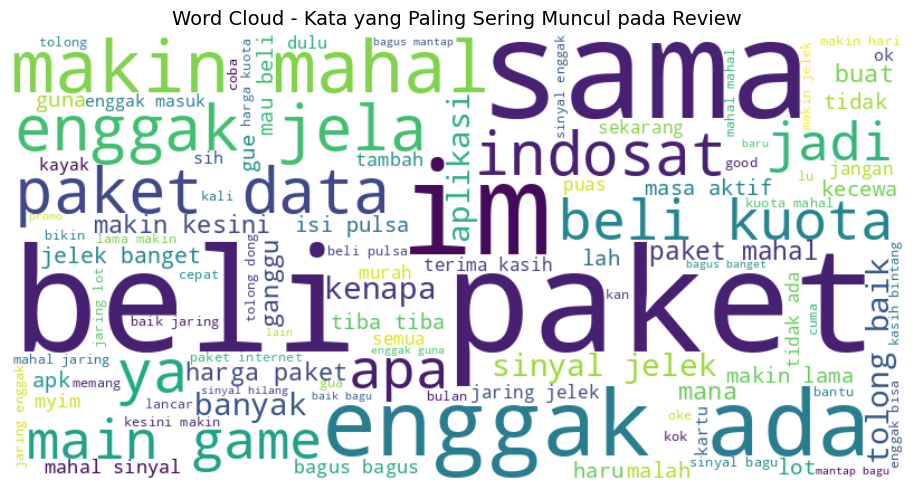

In [ ]:
# Menggabungkan seluruh list kata dari semua baris menjadi satu string raksasa
semua_kata = " ".join(
    [" ".join(teks) for teks in df_preproc["text_stemmed"]]
)

# Konfigurasi parameter Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100,
    colormap="viridis",
    random_state=42,
).generate(semua_kata)

# Menampilkan visualisasi plot
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Word Cloud - Kata yang Paling Sering Muncul pada Review", fontsize=14
)
plt.tight_layout()
plt.show()